In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [5]:
from google.colab import files
uploaded = files.upload()

Saving laptop_data.csv to laptop_data.csv


In [6]:
df = pd.read_csv("laptop_data.csv")
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [7]:
df.shape

(1303, 12)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


In [9]:
df.isnull().sum()*100

,0
Unnamed: 0,0
Company,0
TypeName,0
Inches,0
ScreenResolution,0
Cpu,0
Ram,0
Memory,0
Gpu,0
OpSys,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop(columns = ['Unnamed: 0'], axis=1, inplace=True)
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


#### Feature Engineering

In [12]:
df['Ram'] = df['Ram'].str.replace('GB', '')
df['Weight'] = df['Weight'].str.replace('kg', '')
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080


### Data Cleaning

In [13]:
df.dtypes

,0
Company,object
TypeName,object
Inches,float64
ScreenResolution,object
Cpu,object
Ram,object
Memory,object
Gpu,object
OpSys,object
Weight,object


In [14]:
from numpy import float32
from numpy import int32
df['Ram'] = df['Ram'].astype(int32)
df['Weight'] =df['Weight'].astype(float32)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int32  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   float32
 10  Price             1303 non-null   float64
dtypes: float32(1), float64(2), int32(1), object(7)
memory usage: 101.9+ KB


### EDA

<Axes: xlabel='Price', ylabel='Count'>

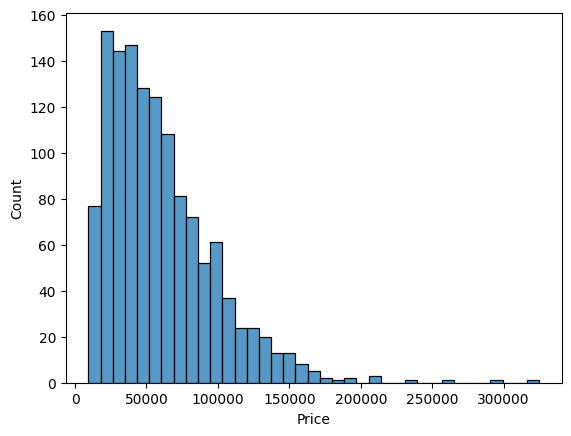

In [16]:
sns.histplot(df['Price'])

<Axes: xlabel='Company'>

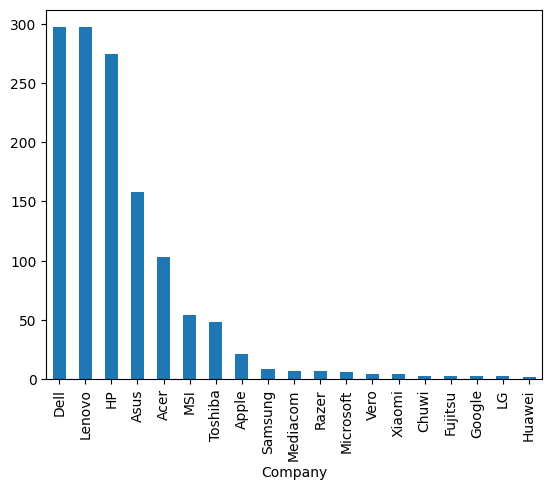

In [17]:
df['Company'].value_counts().plot(kind= 'bar')

<Axes: xlabel='Company'>

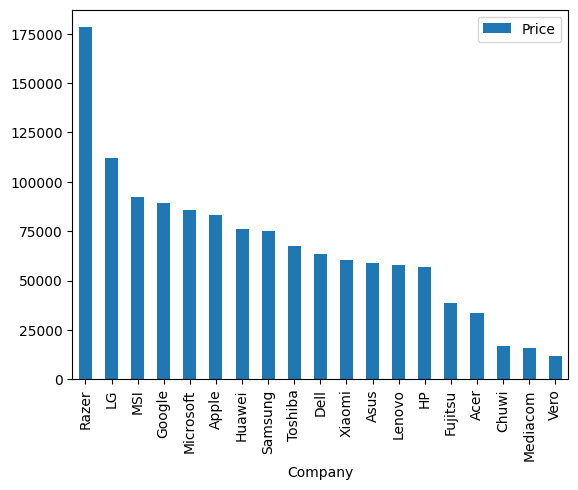

In [18]:
price = df.groupby('Company')[['Price']].mean().sort_values(by='Price', ascending=False).plot(kind='bar')
price

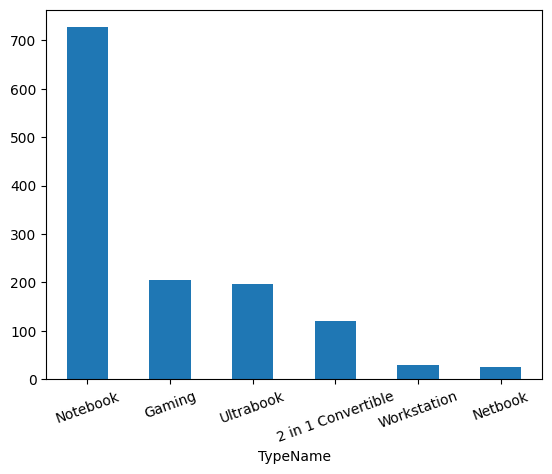

In [19]:
df['TypeName'].value_counts().plot(kind= 'bar')
plt.xticks(rotation=20)
plt.show()

##### Avg Price According to Laptop typename

<Axes: xlabel='TypeName'>

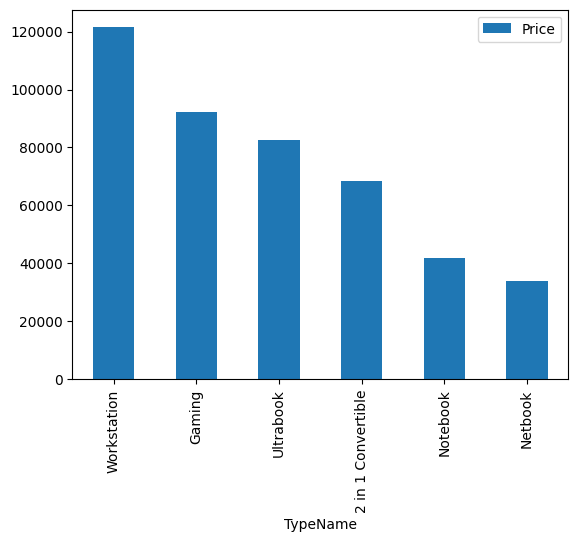

In [20]:
Avg_price = df.groupby('TypeName')[['Price']].mean().sort_values(by = 'Price', ascending=False).plot(kind='bar')
Avg_price

<Axes: ylabel='Frequency'>

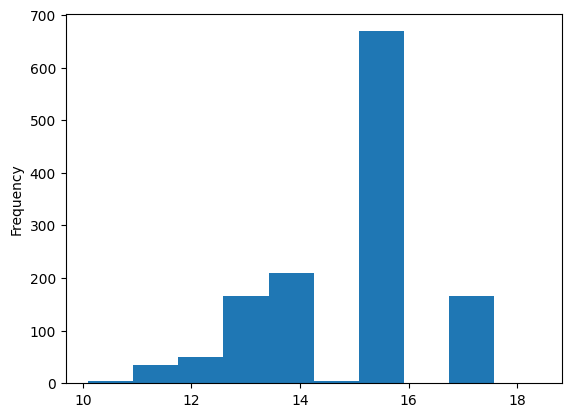

In [21]:
df['Inches'].plot(kind='hist')

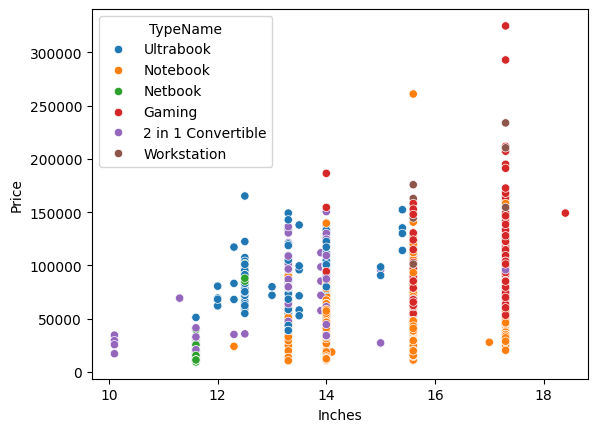

In [22]:
sns.scatterplot(x =df['Inches'],y= df['Price'], hue=df['TypeName'])
plt.show()

In [23]:
df.head(2)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232


In [24]:
df['ScreenResolution'].value_counts()

,count
ScreenResolution,
Full HD 1920x1080,507
1366x768,281
IPS Panel Full HD 1920x1080,230
IPS Panel Full HD / Touchscreen 1920x1080,53
Full HD / Touchscreen 1920x1080,47
1600x900,23
Touchscreen 1366x768,16
Quad HD+ / Touchscreen 3200x1800,15
IPS Panel 4K Ultra HD 3840x2160,12


In [25]:
df['Touchscreen'] = df['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)

In [26]:
df.head(2)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0


<Axes: xlabel='Touchscreen'>

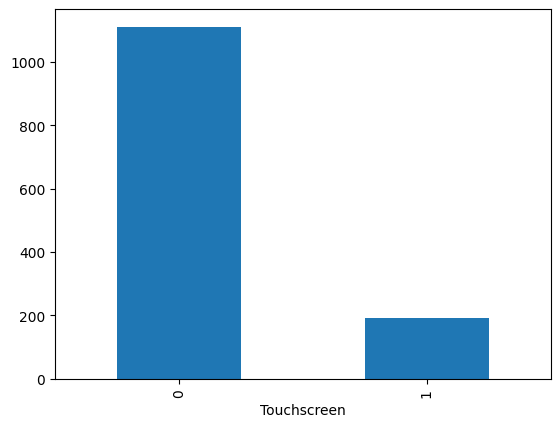

In [27]:
df['Touchscreen'].value_counts().plot(kind= 'bar')

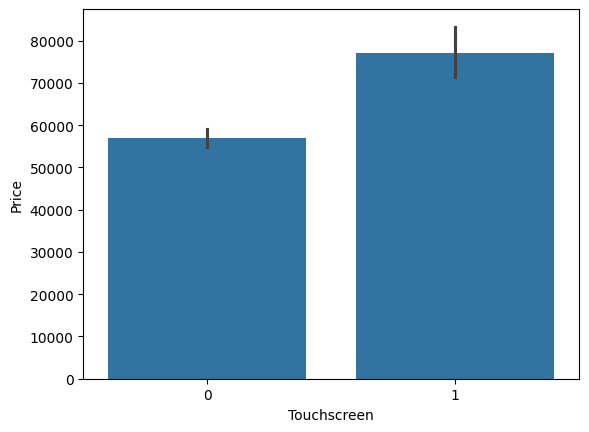

In [28]:
sns.barplot(x= df['Touchscreen'], y =df['Price'])
plt.show()

In [29]:
df['ScreenResolution'].value_counts()

,count
ScreenResolution,
Full HD 1920x1080,507
1366x768,281
IPS Panel Full HD 1920x1080,230
IPS Panel Full HD / Touchscreen 1920x1080,53
Full HD / Touchscreen 1920x1080,47
1600x900,23
Touchscreen 1366x768,16
Quad HD+ / Touchscreen 3200x1800,15
IPS Panel 4K Ultra HD 3840x2160,12


#### We'll create IPS Panel columns

In [30]:
df['IPS_Panel'] = df['ScreenResolution'].apply(lambda x:1 if 'IPS Panel' in x else 0)
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS_Panel
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1


<Axes: xlabel='IPS_Panel'>

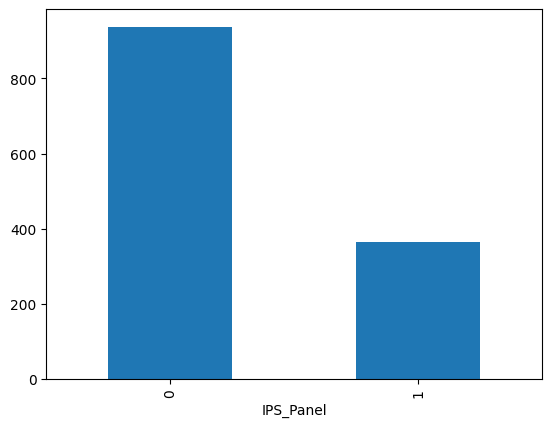

In [31]:
df['IPS_Panel'].value_counts().plot(kind='bar')

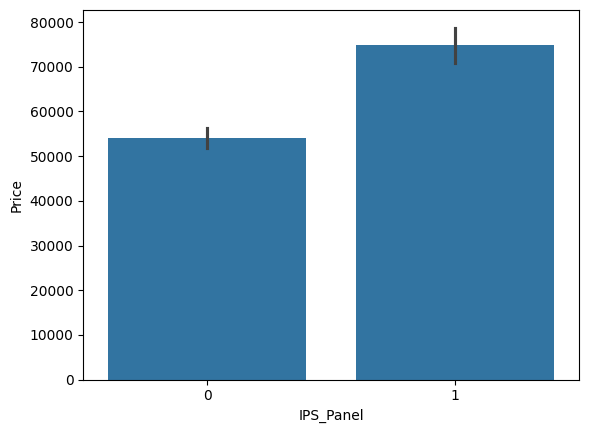

In [32]:
sns.barplot(x =df['IPS_Panel'], y= df['Price'])
plt.show()

#### We Create Two columns X_Resolution and Y_Resolution

In [33]:
new = df['ScreenResolution'].str.split('x', n=1, expand=True)
df['X_Resolution'] = new[0]
df['Y_Resolution'] = new[1]
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS_Panel,X_Resolution,Y_Resolution
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,IPS Panel Retina Display 2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,Full HD 1920,1080
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,IPS Panel Retina Display 2880,1800
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,IPS Panel Retina Display 2560,1600


In [34]:
df['X_Resolution'] = df['X_Resolution'].str.extract(r'(\d+)').astype(int)
print(df['X_Resolution'].head())


0    2560
1    1440
2    1920
3    2880
4    2560
Name: X_Resolution, dtype: int64


In [35]:
df['Y_Resolution'] = df['Y_Resolution'].astype(int32)

In [36]:
df.dtypes

,0
Company,object
TypeName,object
Inches,float64
ScreenResolution,object
Cpu,object
Ram,int32
Memory,object
Gpu,object
OpSys,object
Weight,float32


In [37]:
df.describe()

,Inches,Ram,Weight,Price,Touchscreen,IPS_Panel,X_Resolution,Y_Resolution
count,1303.000000,1303.000000,1303.000000,1303.000000,1303.000000,1303.000000,1303.000000,1303.000000
mean,15.017191,8.382195,2.038734,59870.042910,0.147352,0.280123,1768.193400,1070.830391
std,1.426304,5.084665,0.665475,37243.201786,0.354593,0.449231,470.888913,284.519410
min,10.100000,2.000000,0.690000,9270.720000,0.000000,0.000000,4.000000,768.000000
25%,14.000000,4.000000,1.500000,31914.720000,0.000000,0.000000,1366.000000,900.000000
50%,15.600000,8.000000,2.040000,52054.560000,0.000000,0.000000,1920.000000,1080.000000
75%,15.600000,8.000000,2.300000,79274.246400,0.000000,1.000000,1920.000000,1080.000000
max,18.400000,64.000000,4.700000,324954.720000,1.000000,1.000000,3200.000000,2160.000000


In [38]:
# Calculate correlation only for numeric columns
df.corr(numeric_only=True)

,Inches,Ram,Weight,Price,Touchscreen,IPS_Panel,X_Resolution,Y_Resolution
Inches,1.000000,0.237993,0.827631,0.068197,-0.361735,-0.114804,-0.097039,-0.095404
Ram,0.237993,1.000000,0.383874,0.743007,0.116984,0.206623,0.056815,0.424437
Weight,0.827631,0.383874,1.000000,0.210370,-0.294620,0.016967,-0.115437,-0.053846
Price,0.068197,0.743007,0.210370,1.000000,0.191226,0.252208,0.083832,0.552809
Touchscreen,-0.361735,0.116984,-0.294620,0.191226,1.000000,0.150512,0.057097,0.357930
IPS_Panel,-0.114804,0.206623,0.016967,0.252208,0.150512,1.000000,0.115224,0.289030
X_Resolution,-0.097039,0.056815,-0.115437,0.083832,0.057097,0.115224,1.000000,0.014454
Y_Resolution,-0.095404,0.424437,-0.053846,0.552809,0.357930,0.289030,0.014454,1.000000


In [39]:
df.corr(numeric_only=True)['Price']

,Price
Inches,0.068197
Ram,0.743007
Weight,0.210370
Price,1.000000
Touchscreen,0.191226
IPS_Panel,0.252208
X_Resolution,0.083832
Y_Resolution,0.552809


In [40]:
df.head(2)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS_Panel,X_Resolution,Y_Resolution
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900


#### Create Column PPI(Pixel Per inch)

In [41]:
df['PPI'] = ((df['X_Resolution']**2)+ (df['Y_Resolution']**2))**0.5/df['Inches']
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS_Panel,X_Resolution,Y_Resolution,PPI
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600,226.983005
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900,127.677940
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080,141.211998
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800,220.534624
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600,226.983005


In [42]:
df.corr(numeric_only= True)['PPI']

,PPI
Inches,-0.537159
Ram,0.186012
Weight,-0.449028
Price,0.348331
Touchscreen,0.416460
IPS_Panel,0.287694
X_Resolution,0.636837
Y_Resolution,0.651335
PPI,1.000000


In [43]:
df.drop(columns = ['ScreenResolution','Inches', 'X_Resolution',	'Y_Resolution'], axis=1, inplace=True)

In [44]:
df

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS_Panel,PPI
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005
...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,Intel Core i7 6500U 2.5GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.80,33992.6400,1,1,157.350512
1299,Lenovo,2 in 1 Convertible,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.30,79866.7200,1,1,276.053530
1300,Lenovo,Notebook,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.50,12201.1200,0,0,111.935204
1301,HP,Notebook,Intel Core i7 6500U 2.5GHz,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19,40705.9200,0,0,100.454670


#### Feature Engineerin on cpu column

In [45]:
df['Cpu'].value_counts()

,count
Cpu,
Intel Core i5 7200U 2.5GHz,190
Intel Core i7 7700HQ 2.8GHz,146
Intel Core i7 7500U 2.7GHz,134
Intel Core i7 8550U 1.8GHz,73
Intel Core i5 8250U 1.6GHz,72
...,...
Intel Core i5 7200U 2.70GHz,1
Intel Core M M7-6Y75 1.2GHz,1
Intel Core M 6Y54 1.1GHz,1


In [46]:
df['Cpu_Name'] = df['Cpu'].apply(lambda x:" ".join(x.split()[:3]))

In [47]:
df

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS_Panel,PPI,Cpu_Name
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,Intel Core i7 6500U 2.5GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.80,33992.6400,1,1,157.350512,Intel Core i7
1299,Lenovo,2 in 1 Convertible,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.30,79866.7200,1,1,276.053530,Intel Core i7
1300,Lenovo,Notebook,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.50,12201.1200,0,0,111.935204,Intel Celeron Dual
1301,HP,Notebook,Intel Core i7 6500U 2.5GHz,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19,40705.9200,0,0,100.454670,Intel Core i7


In [48]:
df['Cpu_Name'].value_counts()

,count
Cpu_Name,
Intel Core i7,527
Intel Core i5,423
Intel Core i3,136
Intel Celeron Dual,80
Intel Pentium Quad,27
Intel Core M,19
AMD A9-Series 9420,12
AMD A6-Series 9220,8
Intel Celeron Quad,8


##### We extract only Intel Core i7, Intel Core i5, Intel Core i3 processor

In [49]:
def fetch_processor(text):
  if text == 'Intel Core i7' or text == 'Intel Core i5' or text == 'Intel Core i3':
    return text
  else:
    if text.split()[0] == 'Intel':
      return 'Other Inten Processor'
    else:
      return 'Other Processor'

In [50]:
df['Brand_Name'] = df['Cpu_Name'].apply(fetch_processor)

In [51]:
df.head(5)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS_Panel,PPI,Cpu_Name,Brand_Name
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,Intel Core i5
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,Intel Core i5
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,Intel Core i5
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,Intel Core i7
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,Intel Core i5


In [52]:
df['Brand_Name'].value_counts()

,count
Brand_Name,
Intel Core i7,527
Intel Core i5,423
Other Inten Processor,154
Intel Core i3,136
Other Processor,63


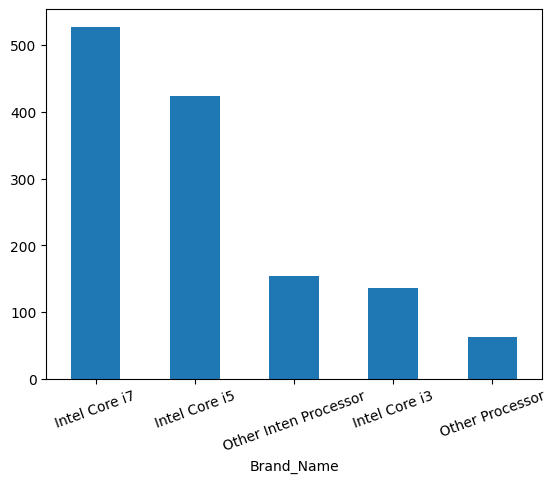

In [53]:
df['Brand_Name'].value_counts().plot(kind= 'bar')
plt.xticks(rotation = 20)
plt.show()

In [54]:
df.columns

Index(['Company', 'TypeName', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight',
       'Price', 'Touchscreen', 'IPS_Panel', 'PPI', 'Cpu_Name', 'Brand_Name'],
      dtype='object')

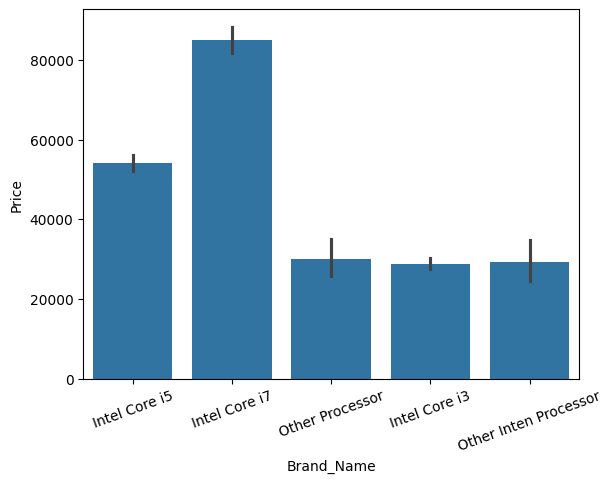

In [55]:
sns.barplot(x =df['Brand_Name'], y= df['Price'])
plt.xticks(rotation = 20)
plt.show()

#### Drop Cpu and Cpu_Name columns

In [56]:
df.drop(columns = ['Cpu', 'Cpu_Name'], axis =1, inplace=True)
df.head()

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS_Panel,PPI,Brand_Name
0,Apple,Ultrabook,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5
1,Apple,Ultrabook,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5
2,HP,Notebook,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5
3,Apple,Ultrabook,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7
4,Apple,Ultrabook,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5


In [57]:
df['Ram'].value_counts()

,count
Ram,
8,619
4,375
16,200
6,41
12,25
2,22
32,17
24,3
64,1


<Axes: xlabel='Ram'>

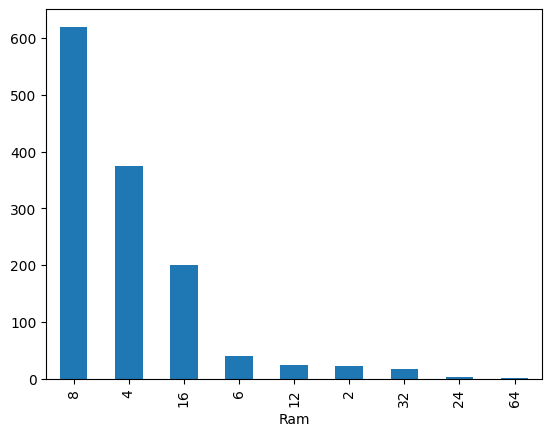

In [58]:
df['Ram'].value_counts().plot(kind ='bar')

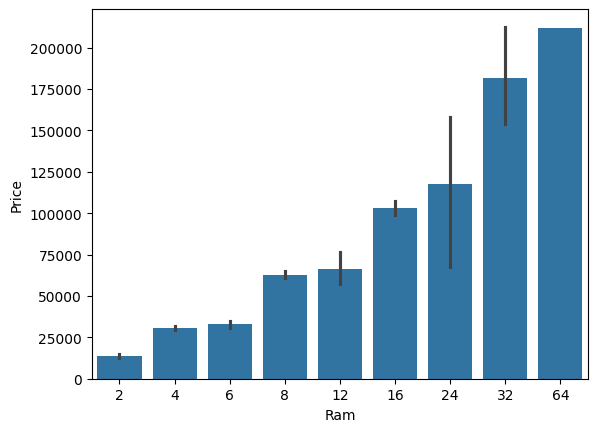

In [59]:
sns.barplot(x =df['Ram'], y= df['Price'])
plt.show()

#### Feature Engineering on Memory Column

In [60]:
df['Memory'].value_counts()

,count
Memory,
256GB SSD,412
1TB HDD,223
500GB HDD,132
512GB SSD,118
128GB SSD + 1TB HDD,94
128GB SSD,76
256GB SSD + 1TB HDD,73
32GB Flash Storage,38
2TB HDD,16


In [61]:
# Use raw string 'r' prefix and regex=True to prevent syntax warnings and ensure replacement
df['Memory'] = df['Memory'].astype(str).str.replace(r'\.0', '', regex=True)
df['Memory'] = df['Memory'].str.replace('GB', '')
df['Memory'] = df['Memory'].str.replace('TB', '000')
new = df['Memory'].str.split("+", n=1, expand=True)

df['first'] = new[0].str.strip()
df['second'] = new[1]

# Layer 1 flags
df['Layer1HDD'] = df['first'].apply(lambda x: 1 if "HDD" in x else 0)
df['Layer1SSD'] = df['first'].apply(lambda x: 1 if "SSD" in x else 0)
df['Layer1Hybrid'] = df['first'].apply(lambda x: 1 if "Hybrid" in x else 0)
df['Layer1Flash_Storage'] = df['first'].apply(lambda x: 1 if "Flash Storage" in x else 0)

# FIX: Added regex=True to ensure non-digits are successfully removed
df['first'] = df['first'].str.replace(r'\D', '', regex=True)

# FIX: Avoid chained assignment warning by re-assigning directly
df['second'] = df['second'].fillna("0")

# Layer 2 flags
df['Layer2HDD'] = df['second'].apply(lambda x: 1 if "HDD" in x else 0)
df['Layer2SSD'] = df['second'].apply(lambda x: 1 if "SSD" in x else 0)
df['Layer2Hybrid'] = df['second'].apply(lambda x: 1 if "Hybrid" in x else 0)
df['Layer2Flash_Storage'] = df['second'].apply(lambda x: 1 if "Flash Storage" in x else 0)

# FIX: Added regex=True here as well
df['second'] = df['second'].str.replace(r'\D', '', regex=True)

# These will now successfully convert to integers
df['first'] = df['first'].astype(int)
df['second'] = df['second'].astype(int)

# Calculate final columns
df['HDD'] = (df['first'] * df['Layer1HDD'] + df["second"] * df['Layer2HDD'])
df['SSD'] = (df['first'] * df['Layer1SSD'] + df["second"] * df['Layer2SSD'])
df['Hybrid'] = (df['first'] * df['Layer1Hybrid'] + df["second"] * df['Layer2Hybrid'])
df['Flash_Storage'] = (df['first'] * df['Layer1Flash_Storage'] + df["second"] * df['Layer2Flash_Storage'])

# Drop helper columns
df.drop(columns=['first', 'second', 'Layer1HDD', 'Layer1SSD', 'Layer1Hybrid',
                 'Layer1Flash_Storage', 'Layer2HDD', 'Layer2SSD', 'Layer2Hybrid',
                 'Layer2Flash_Storage'], axis=1, inplace=True)
df.head()

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS_Panel,PPI,Brand_Name,HDD,SSD,Hybrid,Flash_Storage
0,Apple,Ultrabook,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,0,0
1,Apple,Ultrabook,8,128 Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,0,128
2,HP,Notebook,8,256 SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,0,0
3,Apple,Ultrabook,16,512 SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,0,0
4,Apple,Ultrabook,8,256 SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,0,0


In [62]:
df.sample(3)

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS_Panel,PPI,Brand_Name,HDD,SSD,Hybrid,Flash_Storage
963,Toshiba,Ultrabook,8,512 SSD,Intel HD Graphics 620,Windows 10,1.10,95371.20,1,0,176.232574,Intel Core i7,0,512,0,0
1130,HP,Notebook,8,2000 HDD,Intel HD Graphics 620,Windows 10,2.04,33513.12,0,0,100.454670,Intel Core i7,2000,0,0,0
943,Toshiba,Notebook,8,256 SSD,Intel HD Graphics 520,Windows 10,2.20,59620.32,0,0,100.454670,Intel Core i5,0,256,0,0


In [63]:
df.corr(numeric_only= True)['Price']

,Price
Ram,0.743007
Weight,0.210370
Price,1.000000
Touchscreen,0.191226
IPS_Panel,0.252208
PPI,0.348331
HDD,-0.096441
SSD,0.670799
Hybrid,0.007989
Flash_Storage,-0.040511


In [64]:
df.drop(columns = ['Memory', 'Hybrid', 'Flash_Storage'], axis= 0, inplace = True)
df.head(2)

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,Touchscreen,IPS_Panel,PPI,Brand_Name,HDD,SSD
0,Apple,Ultrabook,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128
1,Apple,Ultrabook,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0


#### Feature Engineering on Gpu columns

In [65]:
df['Gpu'].value_counts()

,count
Gpu,
Intel HD Graphics 620,281
Intel HD Graphics 520,185
Intel UHD Graphics 620,68
Nvidia GeForce GTX 1050,66
Nvidia GeForce GTX 1060,48
...,...
Nvidia Quadro M500M,1
AMD Radeon R7 M360,1
Nvidia Quadro M3000M,1


In [66]:
df['Gpu_BrandName'] = df['Gpu'].apply(lambda x:x.split()[0])

In [67]:
df['Gpu_BrandName'].value_counts()

,count
Gpu_BrandName,
Intel,722
Nvidia,400
AMD,180
ARM,1


In [68]:
df = df[df['Gpu_BrandName'] != 'ARM']

In [69]:
df

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,Touchscreen,IPS_Panel,PPI,Brand_Name,HDD,SSD,Gpu_BrandName
0,Apple,Ultrabook,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,Intel
1,Apple,Ultrabook,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,Intel
2,HP,Notebook,8,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,Intel
3,Apple,Ultrabook,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,AMD
4,Apple,Ultrabook,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,Intel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,4,Intel HD Graphics 520,Windows 10,1.80,33992.6400,1,1,157.350512,Intel Core i7,0,128,Intel
1299,Lenovo,2 in 1 Convertible,16,Intel HD Graphics 520,Windows 10,1.30,79866.7200,1,1,276.053530,Intel Core i7,0,512,Intel
1300,Lenovo,Notebook,2,Intel HD Graphics,Windows 10,1.50,12201.1200,0,0,111.935204,Other Inten Processor,0,0,Intel
1301,HP,Notebook,6,AMD Radeon R5 M330,Windows 10,2.19,40705.9200,0,0,100.454670,Intel Core i7,1000,0,AMD


In [70]:
df['Gpu_BrandName'].value_counts()

,count
Gpu_BrandName,
Intel,722
Nvidia,400
AMD,180


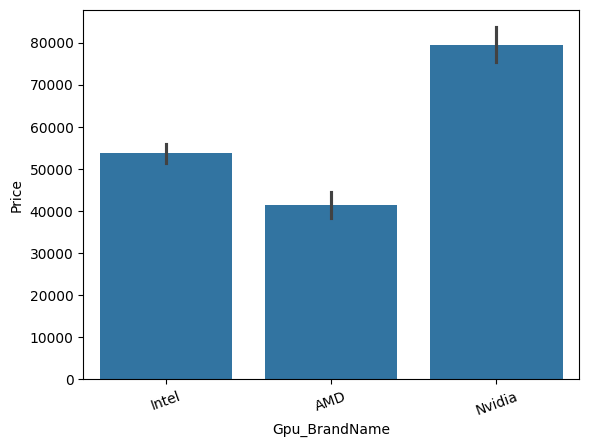

In [71]:
sns.barplot(x =df['Gpu_BrandName'], y= df['Price'])
plt.xticks(rotation = 20)
plt.show()

In [72]:
df.drop(columns= ['Gpu'], axis =1, inplace=True)
df.head(2)

/tmp/ipykernel_887/3788335625.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns= ['Gpu'], axis =1, inplace=True)


,Company,TypeName,Ram,OpSys,Weight,Price,Touchscreen,IPS_Panel,PPI,Brand_Name,HDD,SSD,Gpu_BrandName
0,Apple,Ultrabook,8,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,Intel
1,Apple,Ultrabook,8,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,Intel


In [73]:
df

,Company,TypeName,Ram,OpSys,Weight,Price,Touchscreen,IPS_Panel,PPI,Brand_Name,HDD,SSD,Gpu_BrandName
0,Apple,Ultrabook,8,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,Intel
1,Apple,Ultrabook,8,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,Intel
2,HP,Notebook,8,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,Intel
3,Apple,Ultrabook,16,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,AMD
4,Apple,Ultrabook,8,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,Intel
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,4,Windows 10,1.80,33992.6400,1,1,157.350512,Intel Core i7,0,128,Intel
1299,Lenovo,2 in 1 Convertible,16,Windows 10,1.30,79866.7200,1,1,276.053530,Intel Core i7,0,512,Intel
1300,Lenovo,Notebook,2,Windows 10,1.50,12201.1200,0,0,111.935204,Other Inten Processor,0,0,Intel
1301,HP,Notebook,6,Windows 10,2.19,40705.9200,0,0,100.454670,Intel Core i7,1000,0,AMD


In [74]:
df['OpSys'].value_counts()

,count
OpSys,
Windows 10,1072
No OS,66
Linux,62
Windows 7,45
Chrome OS,26
macOS,13
Mac OS X,8
Windows 10 S,8
Android,2


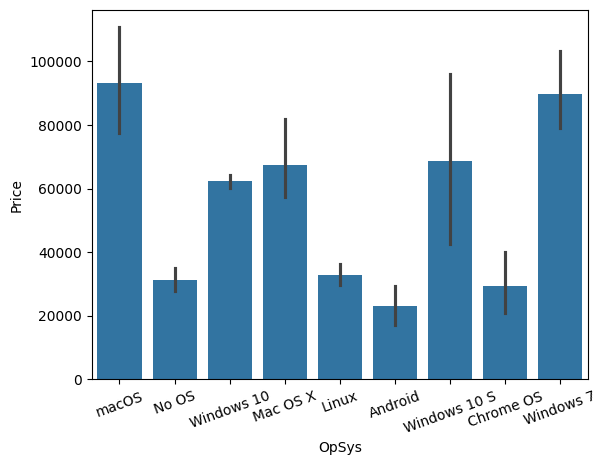

In [75]:
sns.barplot(x =df['OpSys'], y= df['Price'])
plt.xticks(rotation = 20)
plt.show()

### We extract only Windows 10, Windows 7, and Windows 10 s

In [76]:
def cat_os(inp):
    # Standardise text to single spaces to avoid typo bugs
    inp = " ".join(str(inp).split())

    if inp in ['Windows 10', 'Windows 7', 'Windows 10 S']:
        return "Windows"
    elif inp in ['Mac OS X', 'macOS']:
        return 'Mac'
    else:
        return 'Others/No OS/Linux'

df['OpSys_Name'] = df['OpSys'].apply(cat_os)
df.head()

/tmp/ipykernel_887/1800030875.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['OpSys_Name'] = df['OpSys'].apply(cat_os)


,Company,TypeName,Ram,OpSys,Weight,Price,Touchscreen,IPS_Panel,PPI,Brand_Name,HDD,SSD,Gpu_BrandName,OpSys_Name
0,Apple,Ultrabook,8,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,8,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,8,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,Intel,Others/No OS/Linux
3,Apple,Ultrabook,16,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,AMD,Mac
4,Apple,Ultrabook,8,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,Intel,Mac


In [77]:
df.drop(columns = ['OpSys'], axis=1, inplace= True)

/tmp/ipykernel_887/1633586182.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns = ['OpSys'], axis=1, inplace= True)


In [78]:
df

,Company,TypeName,Ram,Weight,Price,Touchscreen,IPS_Panel,PPI,Brand_Name,HDD,SSD,Gpu_BrandName,OpSys_Name
0,Apple,Ultrabook,8,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,8,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,8,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,Intel,Others/No OS/Linux
3,Apple,Ultrabook,16,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,AMD,Mac
4,Apple,Ultrabook,8,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,Intel,Mac
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,4,1.80,33992.6400,1,1,157.350512,Intel Core i7,0,128,Intel,Windows
1299,Lenovo,2 in 1 Convertible,16,1.30,79866.7200,1,1,276.053530,Intel Core i7,0,512,Intel,Windows
1300,Lenovo,Notebook,2,1.50,12201.1200,0,0,111.935204,Other Inten Processor,0,0,Intel,Windows
1301,HP,Notebook,6,2.19,40705.9200,0,0,100.454670,Intel Core i7,1000,0,AMD,Windows


In [79]:
df.dtypes

,0
Company,object
TypeName,object
Ram,int32
Weight,float32
Price,float64
Touchscreen,int64
IPS_Panel,int64
PPI,float64
Brand_Name,object
HDD,int64


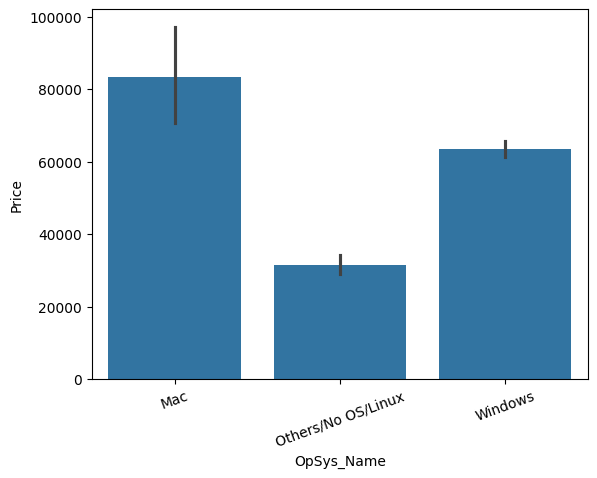

In [80]:
sns.barplot(x =df['OpSys_Name'], y= df['Price'])
plt.xticks(rotation = 20)
plt.show()

<Axes: xlabel='Weight', ylabel='Count'>

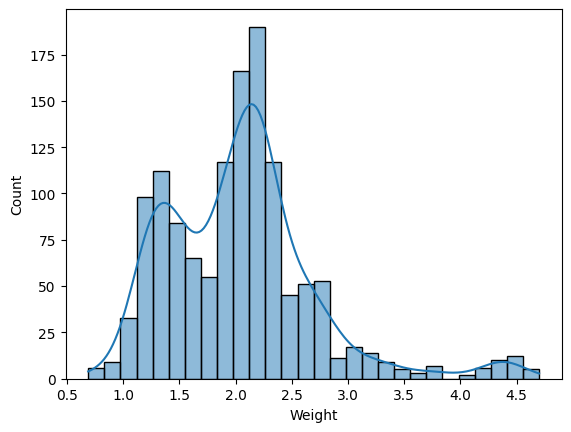

In [81]:
sns.histplot(df['Weight'], kde = True)

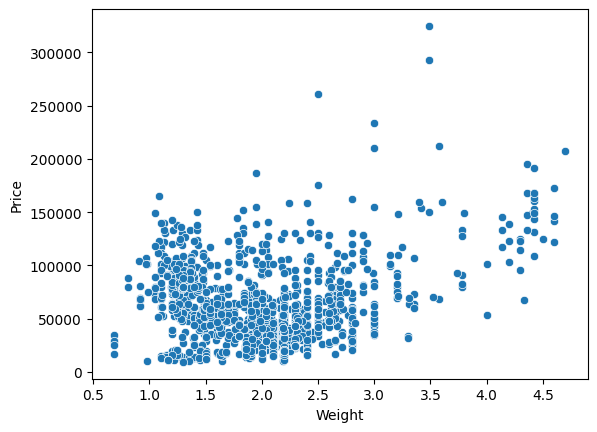

In [82]:
sns.scatterplot(x =df['Weight'], y =df['Price'])
plt.show()

In [83]:
df.corr(numeric_only=True)['Price']

,Price
Ram,0.742905
Weight,0.209867
Price,1.000000
Touchscreen,0.192917
IPS_Panel,0.253320
PPI,0.350885
HDD,-0.096891
SSD,0.670660


In [84]:
df.corr(numeric_only=True) # All correlation of all features

,Ram,Weight,Price,Touchscreen,IPS_Panel,PPI,HDD,SSD
Ram,1.000000,0.383362,0.742905,0.118875,0.207949,0.188494,0.095808,0.603379
Weight,0.383362,1.000000,0.209867,-0.293004,0.018643,-0.447811,0.514147,-0.063818
Price,0.742905,0.209867,1.000000,0.192917,0.253320,0.350885,-0.096891,0.670660
Touchscreen,0.118875,-0.293004,0.192917,1.000000,0.148026,0.413446,-0.208766,0.257577
IPS_Panel,0.207949,0.018643,0.253320,0.148026,1.000000,0.285385,-0.093588,0.225311
PPI,0.188494,-0.447811,0.350885,0.413446,0.285385,1.000000,-0.371272,0.418016
HDD,0.095808,0.514147,-0.096891,-0.208766,-0.093588,-0.371272,1.000000,-0.400750
SSD,0.603379,-0.063818,0.670660,0.257577,0.225311,0.418016,-0.400750,1.000000


<Axes: >

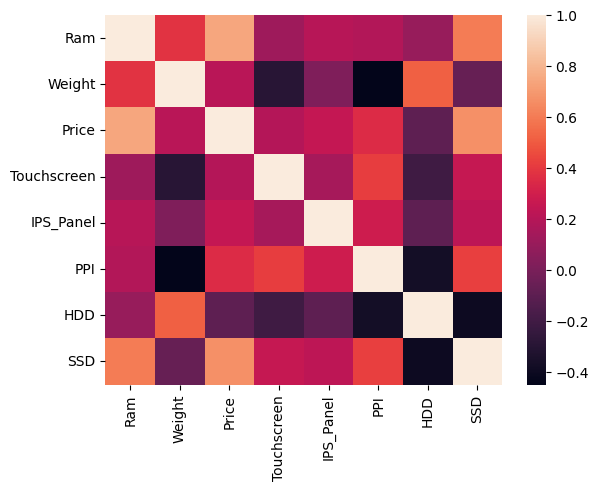

In [85]:
sns.heatmap(df.corr(numeric_only=True))

<Axes: xlabel='Price', ylabel='Count'>

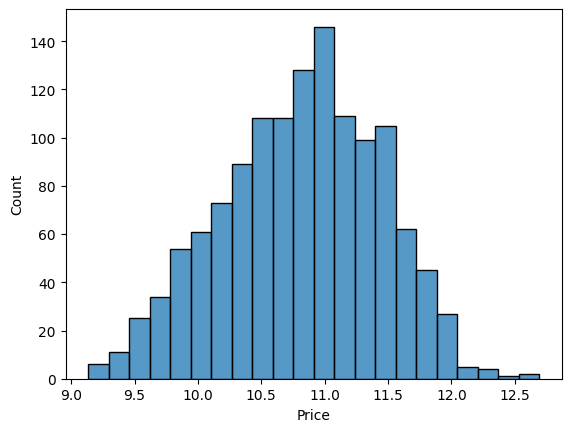

In [86]:
import numpy as np
sns.histplot(np.log(df['Price']))

In [87]:
df.head(2)
print('-'*50)
df.dtypes

--------------------------------------------------


,0
Company,object
TypeName,object
Ram,int32
Weight,float32
Price,float64
Touchscreen,int64
IPS_Panel,int64
PPI,float64
Brand_Name,object
HDD,int64


##### Select Input feature & Target Varriable

In [88]:
X = df.drop(columns = ['Price'])
y= np.log(df['Price'])

In [89]:
X

,Company,TypeName,Ram,Weight,Touchscreen,IPS_Panel,PPI,Brand_Name,HDD,SSD,Gpu_BrandName,OpSys_Name
0,Apple,Ultrabook,8,1.37,0,1,226.983005,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,8,1.34,0,0,127.677940,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,8,1.86,0,0,141.211998,Intel Core i5,0,256,Intel,Others/No OS/Linux
3,Apple,Ultrabook,16,1.83,0,1,220.534624,Intel Core i7,0,512,AMD,Mac
4,Apple,Ultrabook,8,1.37,0,1,226.983005,Intel Core i5,0,256,Intel,Mac
...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,4,1.80,1,1,157.350512,Intel Core i7,0,128,Intel,Windows
1299,Lenovo,2 in 1 Convertible,16,1.30,1,1,276.053530,Intel Core i7,0,512,Intel,Windows
1300,Lenovo,Notebook,2,1.50,0,0,111.935204,Other Inten Processor,0,0,Intel,Windows
1301,HP,Notebook,6,2.19,0,0,100.454670,Intel Core i7,1000,0,AMD,Windows


In [105]:
df["OpSys_Name"].unique()

array(['Mac', 'Others/No OS/Linux', 'Windows'], dtype=object)

In [100]:
X.dtypes

,0
Company,object
TypeName,object
Ram,int32
Weight,float32
Touchscreen,int64
IPS_Panel,int64
PPI,float64
Brand_Name,object
HDD,int64
SSD,int64


#### One hot encoding

In [90]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [91]:
preprocessor = ColumnTransformer(
    transformers=[
        ('col_tnf', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'), [0, 1, 7, 10, 11])
    ],
    remainder='passthrough'
)


### Data Split

In [92]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [93]:
X_train

,Company,TypeName,Ram,Weight,Touchscreen,IPS_Panel,PPI,Brand_Name,HDD,SSD,Gpu_BrandName,OpSys_Name
147,Asus,Notebook,4,2.00,0,0,141.211998,Other Inten Processor,1000,0,Intel,Windows
342,HP,Notebook,8,2.10,0,1,141.211998,Intel Core i3,1000,0,Nvidia,Windows
1003,HP,Notebook,4,1.64,0,0,111.935204,Intel Core i5,500,0,Intel,Windows
814,Dell,Notebook,8,2.18,0,0,141.211998,Intel Core i5,0,256,AMD,Windows
344,Dell,Ultrabook,8,1.20,0,0,165.632118,Intel Core i7,0,256,Intel,Windows
...,...,...,...,...,...,...,...,...,...,...,...,...
1095,Acer,Notebook,8,2.40,0,0,141.211998,Intel Core i5,1000,256,Nvidia,Windows
1130,HP,Notebook,8,2.04,0,0,100.454670,Intel Core i7,2000,0,Intel,Windows
1295,Dell,Notebook,8,2.30,0,0,100.454670,Intel Core i7,1000,0,AMD,Others/No OS/Linux
860,Lenovo,Notebook,8,2.30,0,1,141.211998,Intel Core i5,1000,0,Intel,Windows


#### **Model Building**

In [94]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

In [95]:
models = {
    'LinearRegression': LinearRegression(),
    'DecisionTreeRegressor': DecisionTreeRegressor(max_depth=8),
    'RandomForestRegressor': RandomForestRegressor(
        n_estimators=100, random_state=3, max_samples=0.5, max_features=0.75, max_depth=15),
    'GradientBoostingRegressor': GradientBoostingRegressor(n_estimators=500),
    'AdaBoostRegressor': AdaBoostRegressor(n_estimators=15, learning_rate=1.0),
    'ExtraTreesRegressor': ExtraTreesRegressor(n_estimators=100, random_state=3, max_samples=0.5, max_features=0.75, max_depth=15, bootstrap=True),
    'SVR': SVR(kernel='rbf', C=10000, epsilon=0.1),
    'KNeighborsRegressor': KNeighborsRegressor(n_neighbors=3),
    'XGBRegressor': XGBRegressor(n_estimators=45, max_depth=5, learning_rate=0.5),
    'Ridge Regression': Ridge(alpha=10),
    'Lasso Regression': Lasso(alpha=0.001)
}

In [96]:
results = []
for name, model in models.items():
    pipel = Pipeline([
        ('preproces', preprocessor),
        ('model', model)
    ])

    pipel.fit(X_train, y_train)
    y_pred = pipel.predict(X_test)

    score_1 = pipel.score(X_train, y_train)
    score_2 = pipel.score(X_test, y_test)
    print(f"{name} Accuracy on Traing Data : {score_1}")
    print(f"{name} Accuracy on Testing Data: {score_2}")
    print("-"*50)

    #Model Evaluation
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({"Name": name, "MAE": mae,"MSE": mse, "RMSE": rmse, "R2_Score":r2})


results_df = pd.DataFrame(results).sort_values(by="R2_Score", ascending=False)
print(results_df)

LinearRegression Accuracy on Traing Data : 0.8340719848937983
LinearRegression Accuracy on Testing Data: 0.8052434034775593
--------------------------------------------------
DecisionTreeRegressor Accuracy on Traing Data : 0.9177725182730869
DecisionTreeRegressor Accuracy on Testing Data: 0.8356479349095344
--------------------------------------------------
RandomForestRegressor Accuracy on Traing Data : 0.9509409195048152
RandomForestRegressor Accuracy on Testing Data: 0.8620133272586666
--------------------------------------------------
GradientBoostingRegressor Accuracy on Traing Data : 0.9599651336520376
GradientBoostingRegressor Accuracy on Testing Data: 0.8803340300413525
--------------------------------------------------
AdaBoostRegressor Accuracy on Traing Data : 0.8158233897006274
AdaBoostRegressor Accuracy on Testing Data: 0.7576834644139813
--------------------------------------------------
ExtraTreesRegressor Accuracy on Traing Data : 0.9473232232897939
ExtraTreesRegressor 

#### **Model Save**

In [97]:
models = joblib.dump(models, 'Price_models.pkl')

In [106]:
import joblib

# Save your trained pipeline model
joblib.dump(pipel, "pipeline.pkl")

# Save cleaned dataframe for dropdown selection values in frontend/API schema
joblib.dump(df, "df.pkl")

# Download directly from Colab
from google.colab import files
files.download("pipeline.pkl")
files.download("df.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>